In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import seaborn as sns

!pip install diffrax

In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    "full_landscape": (7.35, 4.40),
    "full_standard": (7.35, 4.90),
    "full_tall": (7.35, 5.50),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "viridis",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="semibold",
        va="top",
        ha="left",
        transform=None,
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


# Example: Lorenz System


Consider the Lorenz system of differential equations:


\begin{align*}
\dot{x} &= \sigma(y-x),\\
\dot{y} &= x(\rho-z)-y,\\
\dot{z} &= xy-\beta z.
\end{align*}


This system has a chaotic attractor for $\sigma=10$, $\beta=8/3$, and $\rho=28$.
We are going to study the sensitivity of the system to its initial conditions.
Our goal is to demonstrate that local sensitivity analysis **is not appropriate** for this system.

Let's code it up and see what it looks like.



In [3]:
import jax.numpy as jnp
from jax import vmap, jit
from functools import partial
from diffrax import diffeqsolve, Tsit5, ODETerm, SaveAt


def solve_lorenz(u0, theta):

    def vector_field(t, u, theta):
        x = u[0]
        y = u[1]
        z = u[2]
        sigma = theta[0]
        beta = theta[1]
        rho = theta[2]
        dx = sigma * (y - x)
        dy = x * (rho - z) - y
        dz = x * y - beta * z
        return jnp.array([dx, dy, dz])

    return diffeqsolve(
        ODETerm(vector_field),
        Tsit5(),
        t0=0.0,
        t1=100.0,
        dt0=0.1,
        y0=u0,
        args=theta,
        saveat=SaveAt(ts=jnp.linspace(0.0, 100.0, 10_000))
    ).ys

In [4]:
monte_carlo_lorenz = jit(vmap(solve_lorenz, in_axes=(0, None)))

sigma = 10.0
beta = 8.0 / 3.0
rho = 28.0
theta = jnp.array([sigma, beta, rho])
u0 = jnp.array([1.0, 1.0, 1.0]).reshape(1, 3)
ys = monte_carlo_lorenz(u0, theta)
ys.shape

(1, 10000, 3)

Plot the first time steps of the solution:

array([<Axes: title={'center': 'Lorenz system'}, xlabel='t', ylabel='u(t)'>],
      dtype=object)

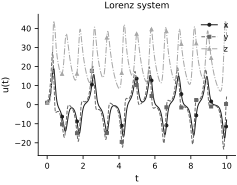

In [5]:
ts = jnp.linspace(0.0, 100.0, 10_000)
steps_to_plot = 1_000

fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
markevery = max(1, steps_to_plot // 12)
ax.plot(ts[:steps_to_plot], ys[0, :steps_to_plot, 0], color="0.10", linestyle="-", marker="o", markevery=markevery, markersize=3, label="x", lw=1.0)
ax.plot(ts[:steps_to_plot], ys[0, :steps_to_plot, 1], color="0.40", linestyle="--", marker="s", markevery=markevery, markersize=3, label="y", lw=1.0)
ax.plot(ts[:steps_to_plot], ys[0, :steps_to_plot, 2], color="0.65", linestyle="-.", marker="^", markevery=markevery, markersize=3, label="z", lw=1.0)
ax.legend(frameon=False)
ax.set(xlabel="t", ylabel="u(t)", title="Lorenz system")
finalize_axes(keep_box=False)

And here is the classic butterfly plot:

array([<Axes3D: title={'center': 'Lorenz system'}, xlabel='x', ylabel='y', zlabel='z'>],
      dtype=object)

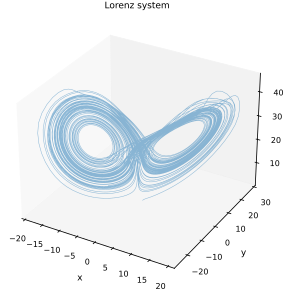

In [6]:
fig = plt.figure(figsize=FIGURE_SIZES["full_standard"])
ax = plt.axes(projection='3d')
ax.plot(ys[0, :, 0], ys[0, :, 1], ys[0, :, 2], lw=0.5, alpha=0.5)
ax.set(xlabel="x", ylabel="y", zlabel="z", title="Lorenz system")
finalize_axes(keep_box=False)


We now take a small cloud of initial conditions and examine how it evolves in time.
We plot the points in dark gray so that the cloud remains visible in black-and-white print.

In [7]:
import numpy as np

mu = np.array([1.0, 1.0, 1.0])
sigma = np.array([0.001, 0.001, 0.001])
num_samples = 1_000
u0_samples = np.random.normal(mu, sigma, size=(num_samples, 3))
ys_samples = monte_carlo_lorenz(u0_samples, theta)
ys_samples.shape

(1000, 10000, 3)

Here we go, the blob at different times:

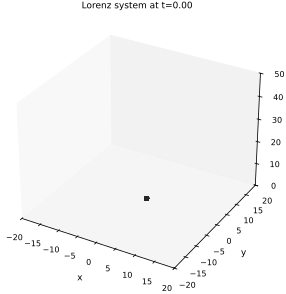

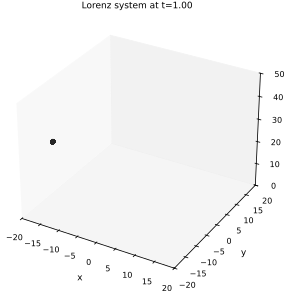

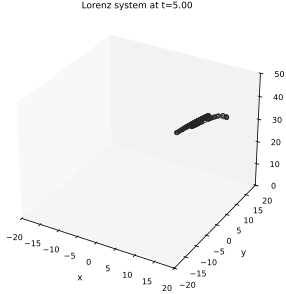

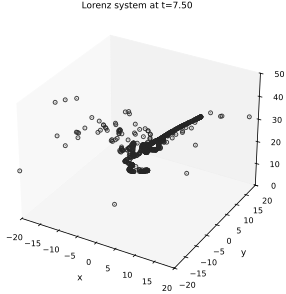

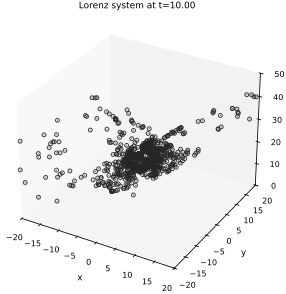

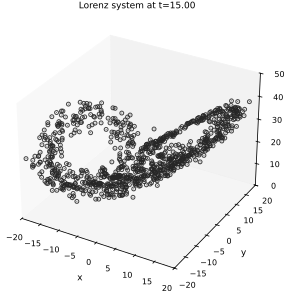

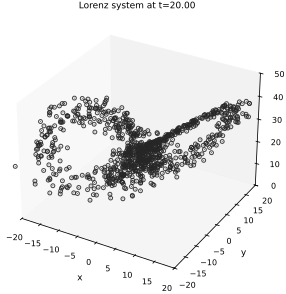

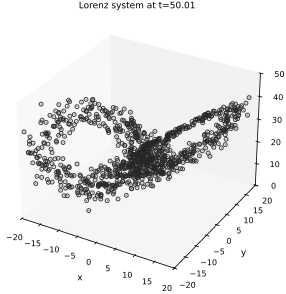

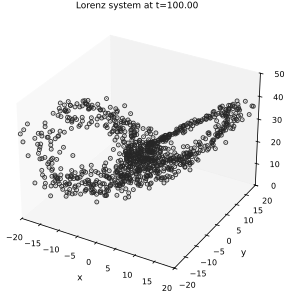

In [8]:
for i in [0, 100, 500, 750, 1_000, 1_500, 2_000, 5_000, 10_000]:
    fig = plt.figure(figsize=FIGURE_SIZES["full_standard"])
    ax = plt.axes(projection='3d')
    ax.plot(ys_samples[:, i, 0], ys_samples[:, i, 1], ys_samples[:, i, 2], '.', color='0.15', alpha=0.85, ms=1.0)
    ax.set(xlabel="x", ylabel="y", zlabel="z", title=f"Lorenz system at t={ts[i]:.2f}")
    finalize_axes(keep_box=False)
    ax.set_xlim(-20, 20)
    ax.set_ylim(-20, 20)
    ax.set_zlim(0, 50)


You see that the tiny blob moved everywhere in the attractor.

What does this mean? We cannot predict the future of the system from the initial conditions even if we know the parameters perfectly.

We know that we will fail, but let's check where local sensitivity analysis will get us.
How far does it predict correctly?

We need to get the Jacobian with respect to the initial conditions.

In [9]:
from jax import jacobian

jit_solve_lorenz = jit(solve_lorenz)
jit_jac_solve_lorenz = jit(jacobian(solve_lorenz, argnums=0))

mu_lorenz = solve_lorenz(mu, theta)
jac_lorenz = jit_jac_solve_lorenz(mu, theta)

Here is the Jacobian.

In [10]:
jac_lorenz.shape

(10000, 3, 3)

Notice that towards the end it has quite a few NaNs:

In [11]:
jac_lorenz;

The NaNs are because of numerical errors. You may have to move to 64-bit floats to get rid of them.
Anyway, local sensitivity analysis will break before that point.
So let's proceed.
I will calculate only the pointwise variance of the time-dependent random state; the full time-time covariance matrix is too large.

In [12]:
var = np.einsum(
    "tij,j,tij->ti",
    jac_lorenz,
    sigma ** 2,
    jac_lorenz
)

Again, I really hope you appreciate the magic of the `einsum` function.
Try to do the above calculation without it.

Let's look at the mean and the variance at specific times:

array([<Axes: title={'center': 'Lorenz system'}, xlabel='t', ylabel='u(t)'>],
      dtype=object)

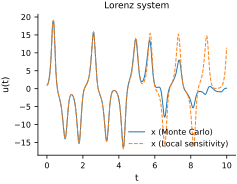

In [13]:
mc_mean = ys_samples.mean(axis=0)

fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
ax.plot(ts[:steps_to_plot], mc_mean[:steps_to_plot, 0], label="x (Monte Carlo)", lw=1)
ax.plot(ts[:steps_to_plot], mu_lorenz[:steps_to_plot, 0], '--', label="x (Local sensitivity)", lw=1)
ax.set(xlabel="t", ylabel="u(t)", title="Lorenz system")
ax.legend(frameon=False)
finalize_axes(keep_box=False)

The variance breaks down even faster:

array([<Axes: title={'center': 'Lorenz system'}, xlabel='t', ylabel='u(t)'>],
      dtype=object)

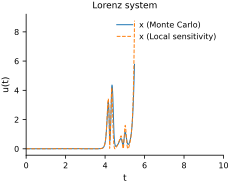

In [14]:
mc_var = ys_samples.var(axis=0)

steps_to_plot = 550
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
ax.plot(ts[:steps_to_plot], mc_var[:steps_to_plot, 0], label="x (Monte Carlo)", lw=1)
ax.plot(ts[:steps_to_plot], var[:steps_to_plot, 0], '--', label="x (Local sensitivity)", lw=1)
ax.set(xlabel="t", ylabel="u(t)", title="Lorenz system")
ax.legend(frameon=False)
ax.set_xlim(0, 10)
finalize_axes(keep_box=False)